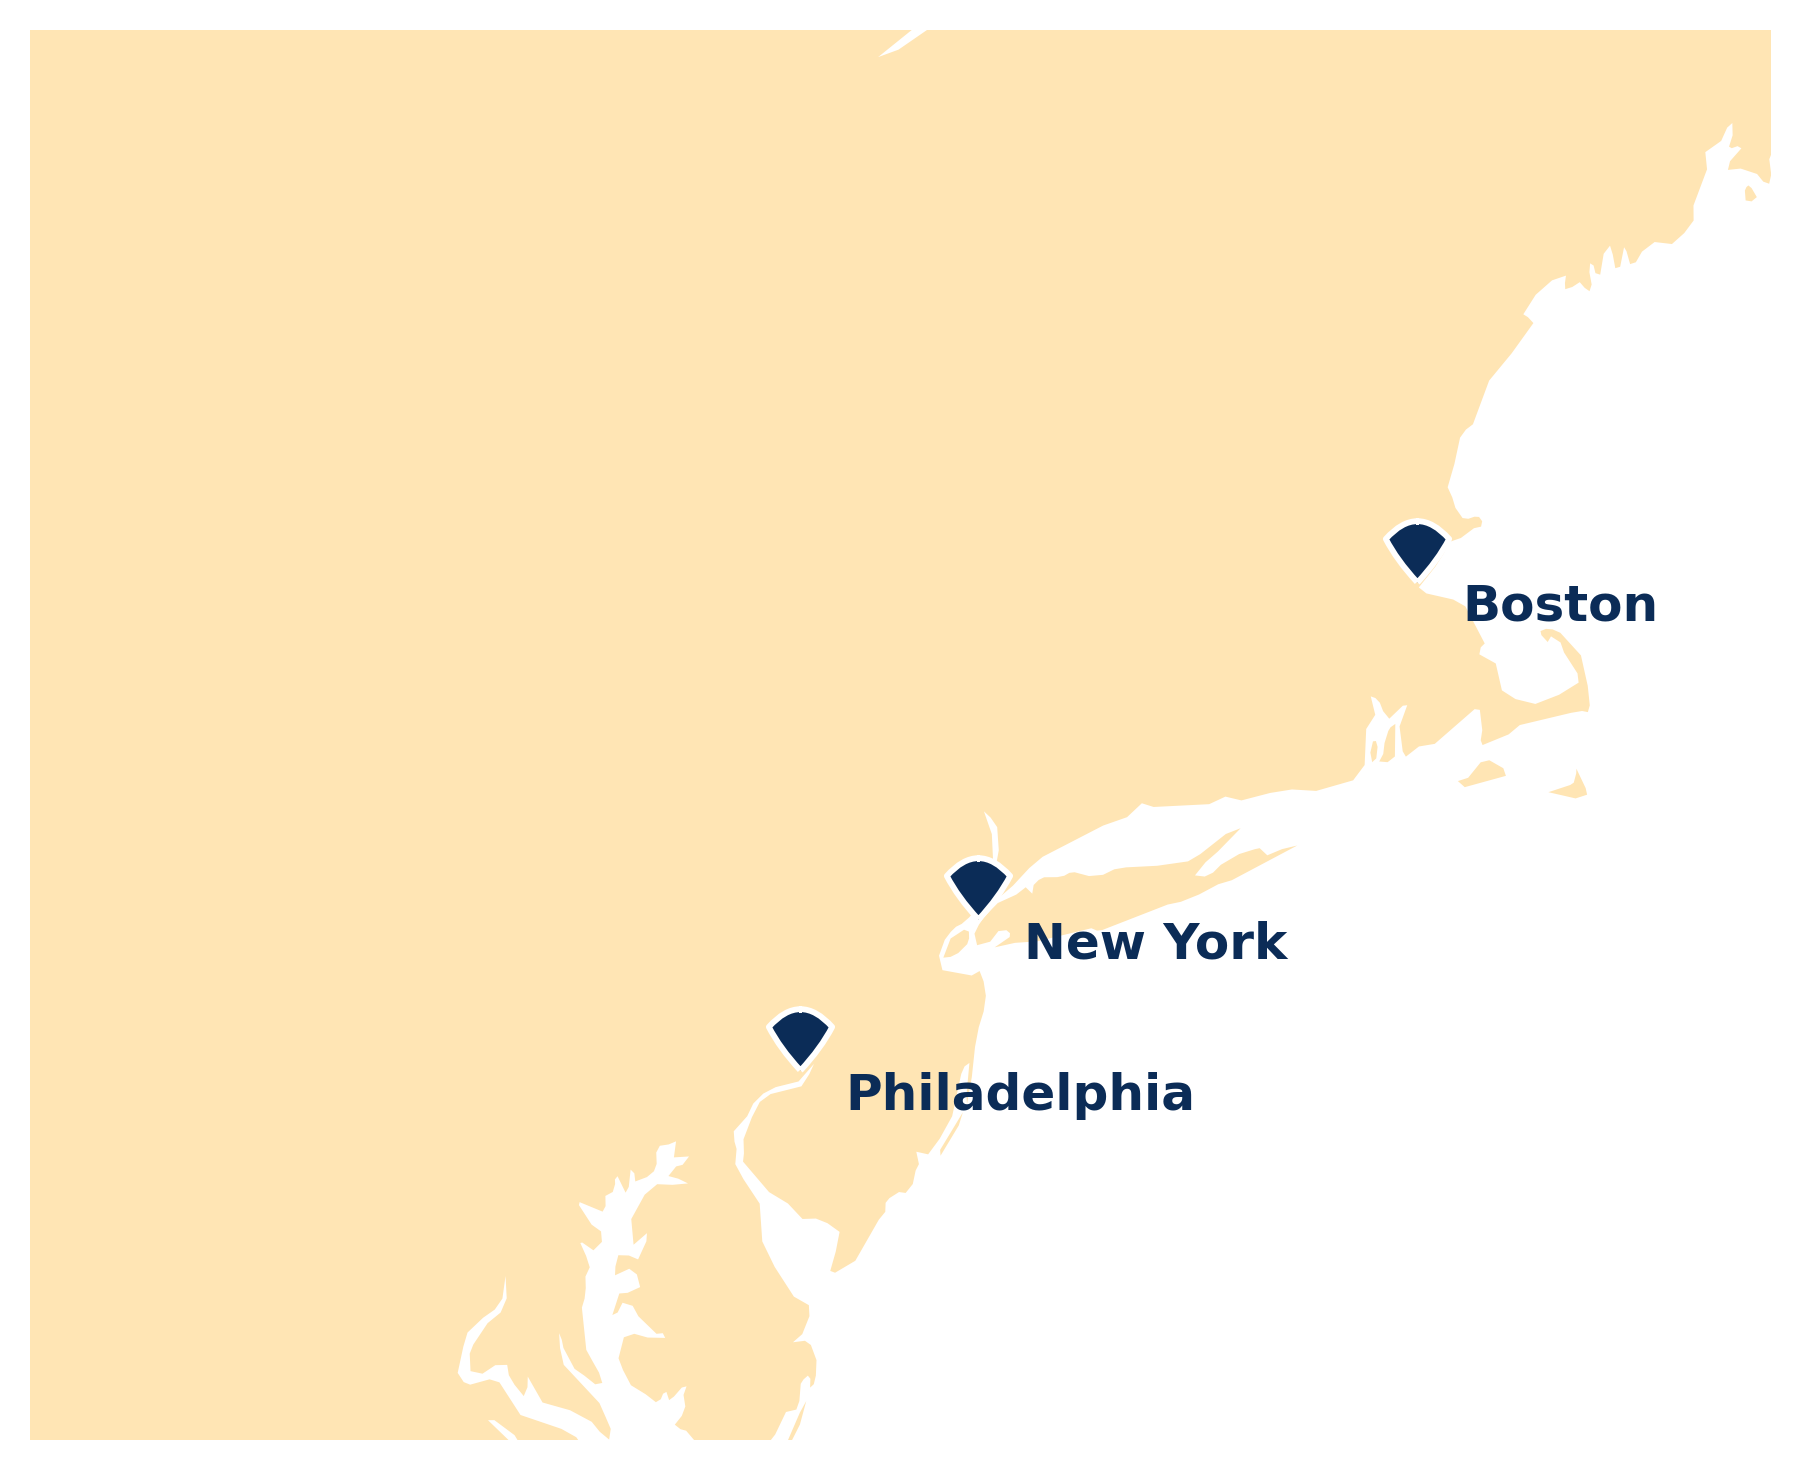

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.path import Path


# =========================
# Datos de las ciudades
# =========================
cities = {
    "New York":     (40.7128, -74.0060),
    "Philadelphia": (39.9526, -75.1652),
    "Boston":       (42.3601, -71.0589),
}


# =========================
# Marcador en forma de GOTA tipo Google Maps
# =========================
verts = [
    (0.0, 0.0),      # punta inferior
    (0.26, 0.28),
    (0.40, 0.55),
    (0.0, 1.0),      # parte superior redondeada
    (-0.40, 0.55),
    (-0.26, 0.28),
    (0.0, 0.0)       # cierre en la punta
]

codes = [
    Path.MOVETO,
    Path.CURVE3,
    Path.CURVE3,
    Path.CURVE3,
    Path.CURVE3,
    Path.CURVE3,
    Path.CLOSEPOLY
]

drop_marker = Path(verts, codes)


# =========================
# Figura y mapa
# =========================
fig = plt.figure(figsize=(10, 5), dpi=300)
proj = ccrs.LambertConformal(central_longitude=-74, central_latitude=41)
ax = plt.axes(projection=proj)

# Zona del noreste de EEUU
ax.set_extent([-80, -69, 38, 45], crs=ccrs.PlateCarree())

# Tierra color melocotón
ax.add_feature(
    cfeature.LAND.with_scale('50m'),
    facecolor="#FFE5B4",
    edgecolor="none"
)


# =========================
# Pintar las ciudades con la gota
# =========================
for name, (lat, lon) in cities.items():
    ax.plot(
        lon, lat,
        marker=drop_marker,
        markersize=38,
        markerfacecolor="#0b2c57",
        markeredgecolor="white",
        markeredgewidth=1.4,
        transform=ccrs.PlateCarree(),
        zorder=5
    )

    ax.text(
        lon + 0.3, lat - 0.2,
        name,
        fontsize=12,
        color="#0b2c57",
        weight="bold",
        transform=ccrs.PlateCarree(),
        zorder=6
    )

# Quitar ejes
ax.axis("off")
plt.tight_layout()

# Guardar transparente
plt.savefig(
    "mapa_dsmarket_gmaps_style.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()
